## SMBHB model 
This notebook provides the photometric model of Super Massive Black Hole Binaries for two components: Doppler boosting and Stochastic Quasar Variability

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from ipywidgets import *

# PlatoSim libraries
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [404]:
# Paths to where data is stored
path = '/lhome/nicholas/software/workdir/smbhb'
fdir = '/lhome/nicholas/Nextcloud/paperSMBHB/figures'

---
## Quasar Gaia DR3 catalogue
---

The catalogues presenetd in this section were generated using `picsim`:

```
python picsim.py --vizier LOPS1 --gaia_quasar --magmax 19 --project smbhb
python picsim.py --vizier LOPN1 --gaia_quasar --magmax 19 --project smbhb
```

In [433]:
# Load catalogues and merge to one
df_LOPS2 = pd.read_feather(f'{path}/input/starcat_GaiaDR3_LOPS2.ftr')
df_LOPN1 = pd.read_feather(f'{path}/input/starcat_GaiaDR3_LOPN1.ftr')
df = pd.concat([df_LOPS2, df_LOPN1])

# Add redshift relative error
df.z_error = np.abs(df.z_upper - df.z_lower) / df.z

# Number of objects
df.shape[0]

19269

### 0. General cuts

In [434]:
# Start make some general cuts
dt0 = df[(df.class_name == 'AGN') & 
         (df. p_comb_quasar > 0.999) & 
         (df.z > 0.09) & 
         (df.z_error < 0.05) &
         (df.Pmag < 19)]
dt0 = dt0.sort_values(by='Pmag', ascending=False)
dt0.p_comb_quasar *= 100

# Number of objects
dt0.shape[0]

12598

### 1. Decontamination cut using proper motion

In [435]:
# Define decontamination line
G_line = np.linspace(5, 19, 100)
mu_line = 10**(0.4*(G_line - 18.25))

# Mark outliers
mu = 10**(0.4*(dt0.Pmag - 18.25))
do1 = dt0[(dt0.pm > mu)]
dt1 = dt0[(dt0.pm < mu)]

# Number of objects
dt1.shape[0]

12586

<IPython.core.display.Javascript object>


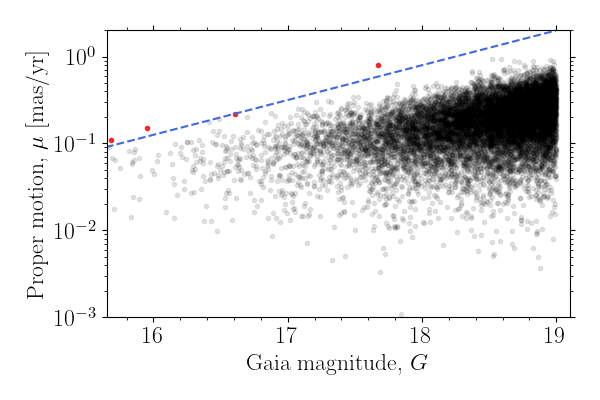

In [436]:
# Plot decontamination
fig = plt.figure(figsize=(6,4))
plt.plot(dt1.Pmag, dt1.pm, '.', c='k', alpha=0.1)
plt.plot(do1.Pmag, do1.pm, '.', c='r', alpha=0.8)
plt.plot(G_line, mu_line, '--', c='royalblue')
plt.xlabel(r'Gaia magnitude, $G$')
plt.ylabel(r'Proper motion, $\mu$ [mas/yr]')
plt.yscale('log')
plt.xlim(min(dt.Pmag)-0.1, max(dt.Pmag)+0.1)
plt.ylim(1e-3, 2e0)
plt.tight_layout();

### 3. Astrometric fidelity cut (Rubizki+2022)

### 2. QSO probability cut

In [437]:
# Remove sources below black line above
do2 = dt1
def y(x): return x 
dt2 = dt1[(10**dt1.qso_non > 2.5) & (dt1.qso_non > y(dt1.qso_var))]

# Number of objects
dt2.shape[0]

12022

<IPython.core.display.Javascript object>


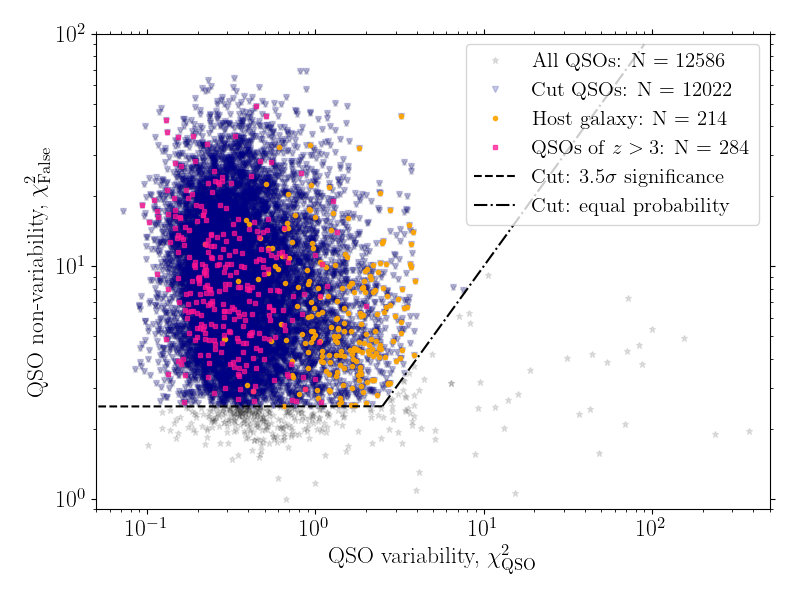

In [438]:
# Plot diagnostic diagram of Butler and Bloom (2011)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Check how many of the AGNs that has a confirmed host galaxy
dh2 = dt2[(dt2.host_galaxy == True)]

# All quasar above z > 3
ds2 = dt2[dt2.z > 3]

# Plotting
ax.plot(10**do2.qso_var, 10**do2.qso_non, '*', c='k',        alpha=0.1, ms=5, label=f'All QSOs: N = {do2.shape[0]}')
ax.plot(10**dt2.qso_var, 10**dt2.qso_non, 'v', c='darkblue', alpha=0.2, ms=5, label=f'Cut QSOs: N = {dt2.shape[0]}')
ax.plot(10**dh2.qso_var, 10**dh2.qso_non, '.', c='orange',   alpha=0.9,       label=f'Host galaxy: N = {dh2.shape[0]}')
ax.plot(10**ds2.qso_var, 10**ds2.qso_non, 's', c='deeppink', alpha=0.7, ms=3, label=r'QSOs of $z>3$: ' + f'N = {ds2.shape[0]}')
ax.plot([0, 2.5], [1, 2.5],         '--', c='k', label=r'Cut: 3.5$\sigma$ significance')
ax.plot([2.5, 90], [y(2.5), y(90)], '-.', c='k', label='Cut: equal probability')
# ax.axvline(x=2.0,         ls='--', c='deeppink', label=r'Cut: higher purity for $z>3$')

# Settings
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'QSO variability, $\chi_{\rm QSO}^2$')
ax.set_ylabel(r'QSO non-variability, $\chi_{\rm False}^2$')
ax.set_xlim(5e-2, 5e2)
ax.set_ylim(0.9, 100)
plt.tight_layout();

# Save figure
fig.savefig(f'{fdir}/variability_QSO.png', bbox_inches='tight', dpi=300)

### 3. Compare to Quaia catalogue (Storey-Fisher+2024)

In [439]:
# Load Quaia catalogue
filename = f'{path}/quaia_G20.5.fits'
from astropy.table import Table
data = Table.read(filename, format='fits')
dx3 = data.to_pandas()
dx3.head()

,source_id,unwise_objid,redshift_quaia,redshift_quaia_err,ra,dec,l,b,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mag_w1_vg,mag_w2_vg,pm,pmra,pmdec,pmra_error,pmdec_error
0,6459630980096,b'0453p000o0014479',0.416867,0.060812,44.910498,0.189649,176.659434,-48.835164,20.173105,20.200150,18.871586,14.774343,13.923867,0.383797,0.217806,-0.316007,0.679419,0.608799
1,10892037246720,b'0453p000o0015876',1.736468,0.096594,45.188575,0.282424,176.851544,-48.570856,18.787239,19.080688,18.240915,15.219950,13.868094,0.155406,-0.098037,-0.120580,0.257395,0.223107
2,15839839588736,b'0453p000o0017020',1.513049,0.063187,45.189480,0.359195,176.769129,-48.516842,18.888464,19.171280,18.509371,15.317786,14.013617,0.448925,-0.316088,0.318781,0.360595,0.326582
3,19275813399552,b'0453p000o0024506',2.422632,0.055260,44.835496,0.237432,176.527928,-48.855622,20.330523,20.320410,19.841410,17.273508,16.396996,1.085342,1.062588,0.221073,0.739487,0.625105
4,22780506725760,b'0453p000o0016209',2.852854,0.076640,44.799365,0.303557,176.417664,-48.835309,19.218422,19.486340,18.814501,16.027142,15.041919,0.523211,0.168237,0.495425,0.361439,0.269473


In [440]:
# Match catalogues
dt2.gaiaDR3 = dt2.gaiaDR3.astype(np.int64)
dt3 = dt2[dt2['gaiaDR3'].isin(dx3['source_id'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)
dx3 = dx3[dx3['source_id'].isin(dt3['gaiaDR3'])].sort_values(by=['source_id']).reset_index(drop=True)

# Number of objects
dt3.shape[0]

11859

In [441]:
# Sperate LOPS2 and LOPN1
ds3 = dt3[dt3.dec < 0]
dn3 = dt3[dt3.dec > 0]

ds3.shape[0], dn3.shape[0]

(5533, 6326)

### Plots for paper 

<IPython.core.display.Javascript object>


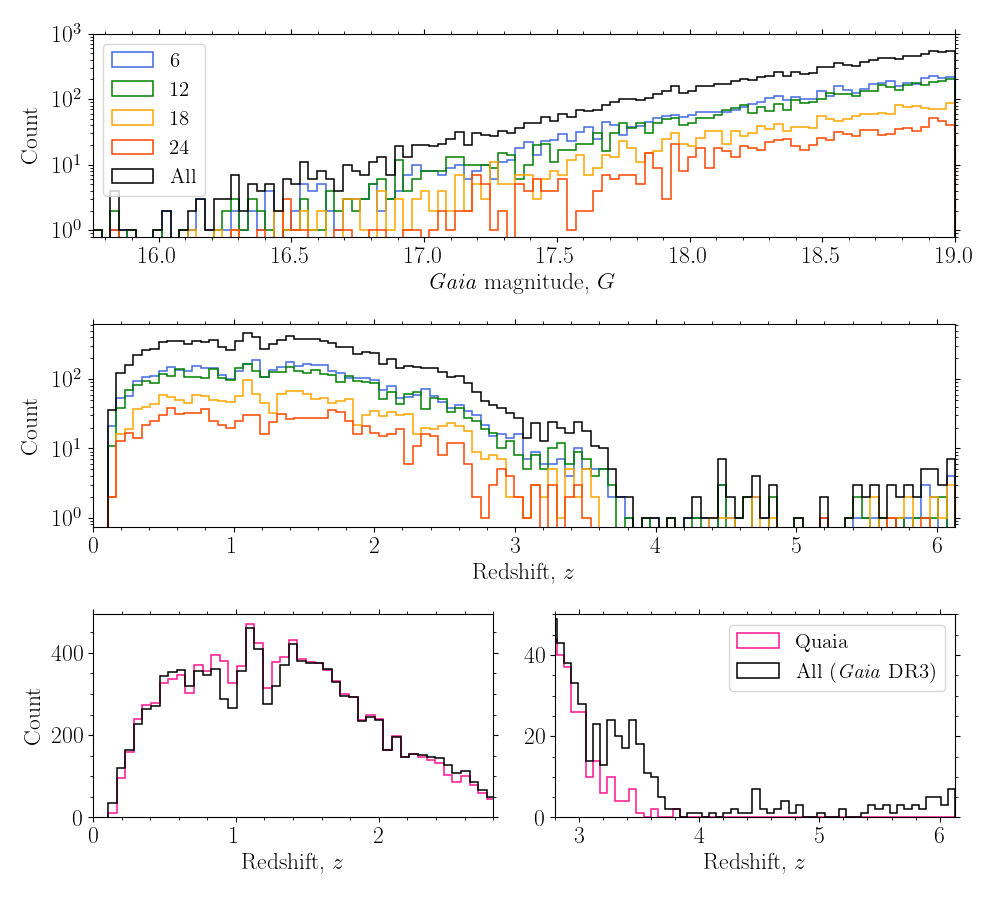

In [447]:
# Seperate camera visibility
dt06 = dt3[dt3.ncams ==  6]
dt12 = dt3[dt3.ncams == 12]
dt18 = dt3[dt3.ncams == 18]
dt24 = dt3[dt3.ncams == 24]

# Plot settings
N = 100
lw = 1.1
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
cols = 3

# fig, ax = plt.subplots(cols, 1, figsize=(9,3*cols))
fig = plt.figure(figsize=(10,3*cols))

ax1 = plt.subplot(3, 1, 1)
P_min, P_max = dt.Pmag.min(), dt.Pmag.max()
ax1.hist(dt06.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(dt3.Pmag,  bins=N, range=(P_min, P_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(P_min, 19)
ax1.set_ylim(0.8, 1000)
ax1.legend(loc='upper left')
ax1.set_yscale('log')

ax2 = plt.subplot(3, 1, 2)
z_min, z_max = dt.z.min(), dt.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(dt3.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'Redshift, $z$')
ax2.set_xlim(0, z_max)
ax2.set_yscale('log')

z_break = 2.8
ax3 = plt.subplot(3, 2, 5)
ax3.hist(dx3.redshift_quaia, bins=N, range=(z_min, z_max), histtype='step', ec='deeppink', lw=lw)
ax3.hist(dt3.z, bins=N, range=(z_min, z_max), histtype='step', ec='k', lw=lw)
ax3.set_xlabel(r'Redshift, $z$')
ax3.set_xlim(0, z_break)

ax4 = plt.subplot(3, 2, 6)
ax4.hist(dx3.redshift_quaia, bins=N, range=(z_min, z_max), histtype='step', ec='deeppink', lw=lw, label='Quaia')
ax4.hist(dt3.z, bins=N, range=(z_min, z_max), histtype='step', ec='k', lw=lw, label=r'All (\textit{Gaia} DR3)')
ax4.set_xlabel(r'Redshift, $z$')
ax4.set_xlim(z_break, z_max)
ax4.set_ylim(0, 50)
ax4.legend(loc='upper right')

for ax in [ax1, ax2, ax3]:
    ax.set_ylabel('Count')
    if ax == ax3:
        ax.get_yaxis().set_label_coords(-0.12, 0.5)
    else:
        ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()

fig.savefig(f'{fdir}/historgram_quasars.png', bbox_inches='tight', dpi=300)

<IPython.core.display.Javascript object>


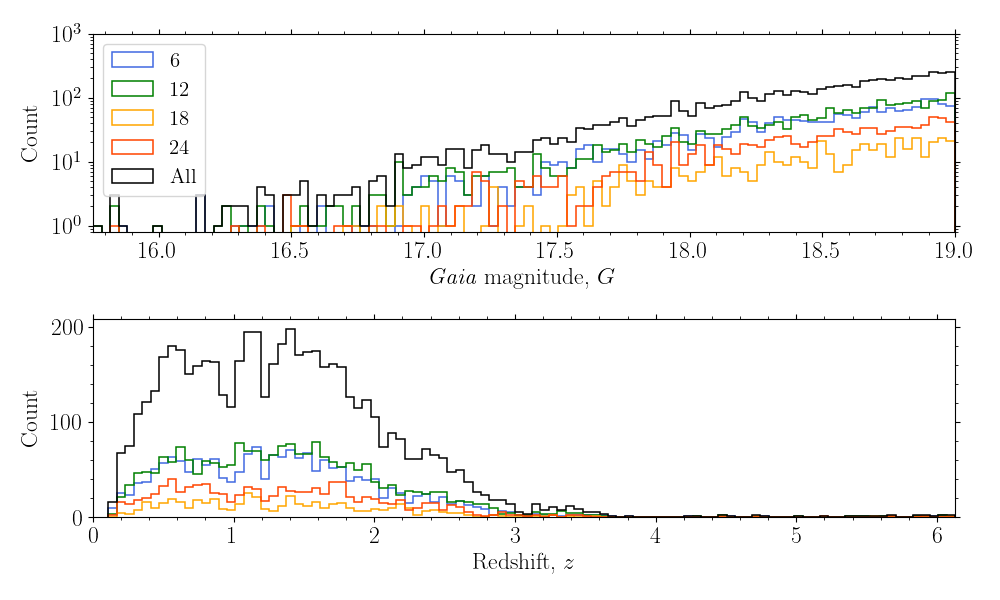

In [450]:
# Seperate camera visibility
dt06 = ds3[ds3.ncams ==  6]
dt12 = ds3[ds3.ncams == 12]
dt18 = ds3[ds3.ncams == 18]
dt24 = ds3[ds3.ncams == 24]

# Plot settings
N = 100
lw = 1.1
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
cols = 2

# fig, ax = plt.subplots(cols, 1, figsize=(9,3*cols))
fig = plt.figure(figsize=(10,3*cols))

ax1 = plt.subplot(2, 1, 1)
P_min, P_max = ds3.Pmag.min(), ds3.Pmag.max()
ax1.hist(dt06.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(ds3.Pmag,  bins=N, range=(P_min, P_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(P_min, 19)
ax1.set_ylim(0.8, 1000)
ax1.legend(loc='upper left')
ax1.set_yscale('log')

ax2 = plt.subplot(2, 1, 2)
z_min, z_max = ds3.z.min(), ds3.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(ds3.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'Redshift, $z$')
ax2.set_xlim(0, z_max)
# ax2.set_yscale('log')

for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
    if ax == ax3:
        ax.get_yaxis().set_label_coords(-0.12, 0.5)
    else:
        ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()

<IPython.core.display.Javascript object>


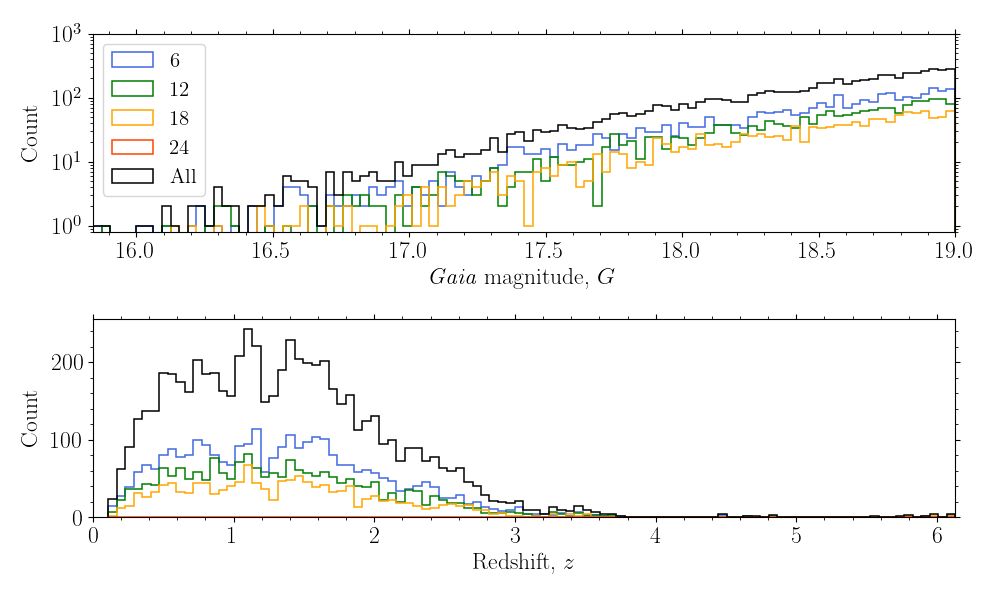

In [451]:
# Seperate camera visibility
dt06 = dn3[dn3.ncams ==  6]
dt12 = dn3[dn3.ncams == 12]
dt18 = dn3[dn3.ncams == 18]
dt24 = dn3[dn3.ncams == 24]

# Plot settings
N = 100
lw = 1.1
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
cols = 2

# fig, ax = plt.subplots(cols, 1, figsize=(9,3*cols))
fig = plt.figure(figsize=(10,3*cols))

ax1 = plt.subplot(2, 1, 1)
P_min, P_max = dn3.Pmag.min(), dn3.Pmag.max()
ax1.hist(dt06.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(dn3.Pmag,  bins=N, range=(P_min, P_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(P_min, 19)
ax1.set_ylim(0.8, 1000)
ax1.legend(loc='upper left')
ax1.set_yscale('log')

ax2 = plt.subplot(2, 1, 2)
z_min, z_max = ds3.z.min(), ds3.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(dn3.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'Redshift, $z$')
ax2.set_xlim(0, z_max)
# ax2.set_yscale('log')

for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
    if ax == ax3:
        ax.get_yaxis().set_label_coords(-0.12, 0.5)
    else:
        ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()

<IPython.core.display.Javascript object>


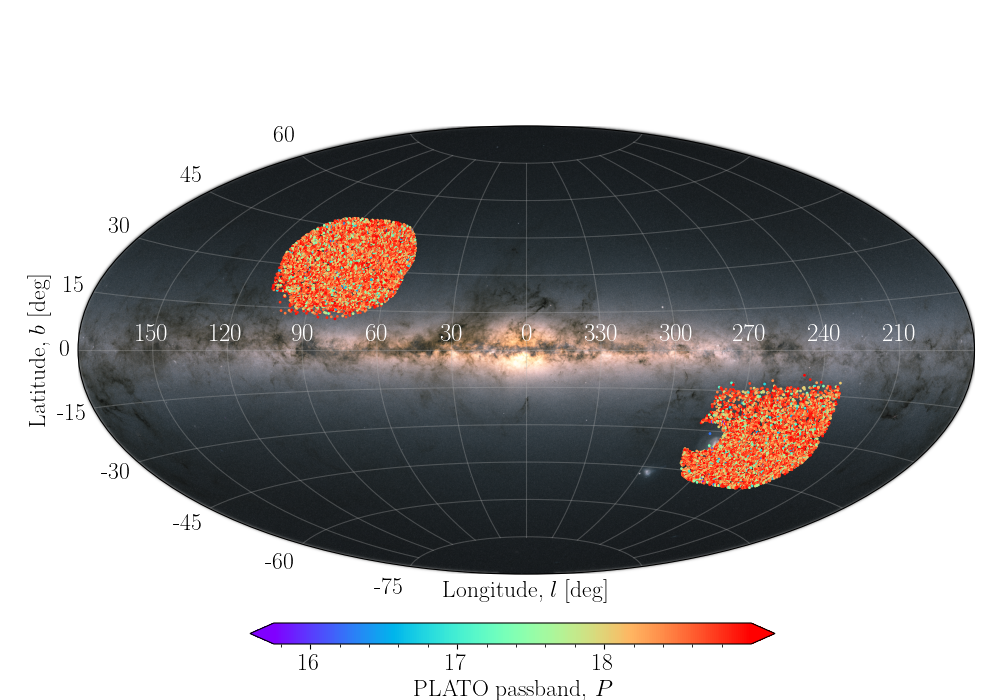

In [406]:
fig, ax = pt.drawStarsInSkyAitoff(dt.ra, dt.dec, magStars=dt.Pmag, fs=17, figsize=(10,7))
fig.savefig(f'{fdir}/aitoff_projection.png', bbox_inches='tight', dpi=300)

In [ ]:
# Seperate LOPS2 and LOPN1 objects


In [179]:
# dx = dt[(dt.z > 0.9) & (dt.z < 1.2)]
# dx = dt[(dt.z < 0.9)]
# fig, ax = pt.drawStarsInSkyAitoff(dx.ra, dx.dec, magStars=dx.Pmag, fs=14, figsize=(10,7))

---
## Physical model
---

### Example: Model Spikey 
Finally we define our constants and parameters of the SPIKEY SMBHB. We also define the time series here and convert necessary units from (seconds) to Modified Julian Date for a better comparison with the light curve produced by Hu et.al  

In [4]:
from platosim.varsource import SMBHB

In [48]:
# Parameters relating to Spikey (SI units)
z  = 0.962
P  = 1.144 * ut.year() * u.s                              
t0 = P * 3/4
M1 = 10**7.4 * u.M_sun                                                           
M2 = 10**6.7 * u.M_sun                                                                                                                      
e  = 0.524
i  = np.rad2deg(np.arccos(0.140)) * u.deg 
I  = 90 * u.deg - i
J  = np.pi/4 * u.deg  
w  = np.rad2deg(1.477) * u.deg
alpha = 2.09
F_lum = 0.89
wvl_c = 600 * u.nm

# Initialise model
dt   = 25
tdur = ut.year() * 3
time = np.arange(0, tdur, dt) * u.s                          
model = SMBHB(time, seed=12345)

### Grantional lensing

In [6]:
# A = model.gravitational_lensing(z, t0, P, M1, M2, I, J, wvl=None)

In [7]:
# # Lensing events
# A1, A2, A = model.gravitational_lensing(t0, P, M1, M2, I, J, z)
# # flux_lens = (1 - flux_lum) * A1 + flux_lum * A2

# time = time.to('d')[::10000]
# fig = plt.figure(figsize = (8, 4))
# plt.plot(time, A1,        ':',  c='orange', label=r"$A_1$")
# plt.plot(time, A2,        '-.', c='orange', label=r"$A_2$")
# plt.plot(time, A,        '-', c='orange', label=r"$A$")
# # plt.plot(time.to('d'), flux_lens, '-',  c='orange', label=r"Lensing")
# # plt.plot(A1,        '-', c='orange', label=r"$A$")
# # plt.plot(A2,        '-', c='orange', label=r"$A$")

# # phi = np.linspace(0, 2*np.pi, len(time))
# # plt.plot(phi, A1,        ':',  c='orange', label=r"$A_1$")
# # plt.plot(phi, A2,        '-.', c='orange', label=r"$A_2$")
# # plt.plot(phi, flux_lens, '-',  c='orange', label=r"Lensing")

# plt.xlabel(r"Time [day]")
# plt.ylabel(r"Relative flux")
# # plt.xlim(0, time.to('d').value[-1])
# plt.legend()
# plt.tight_layout()

<IPython.core.display.Javascript object>


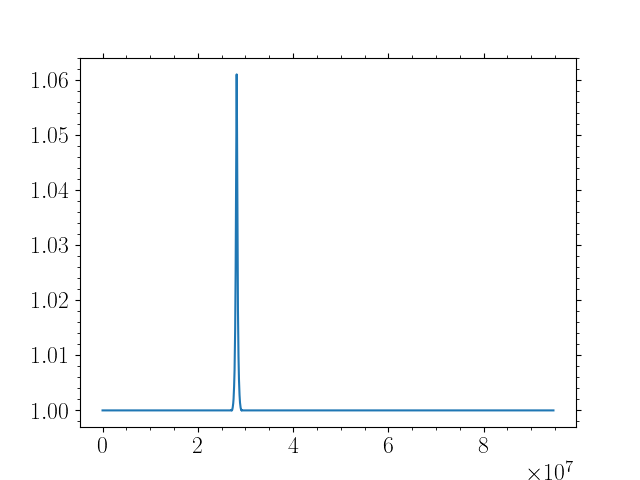

In [49]:
dx = pd.read_feather(f'{path}/lensing_model.ftr')

time0 = np.arange(0, t0.value, 25)
time1 = np.arange(t0.value, t0.value+25*dx.shape[0], 25)
time2 = np.arange(t0.value+25*dx.shape[0], tdur, 25)
time_lens = np.concatenate((time0, time1, time2))

flux0 = time0 * 0
flux1 = (dx.flux-dx.flux.min()) / 14
flux2 = time2 * 0
flux_lens = np.concatenate((flux0, flux1, flux2)) + 1

fig = plt.figure()
plt.plot(time_lens, flux_lens);

### Doppler boosting

<IPython.core.display.Javascript object>


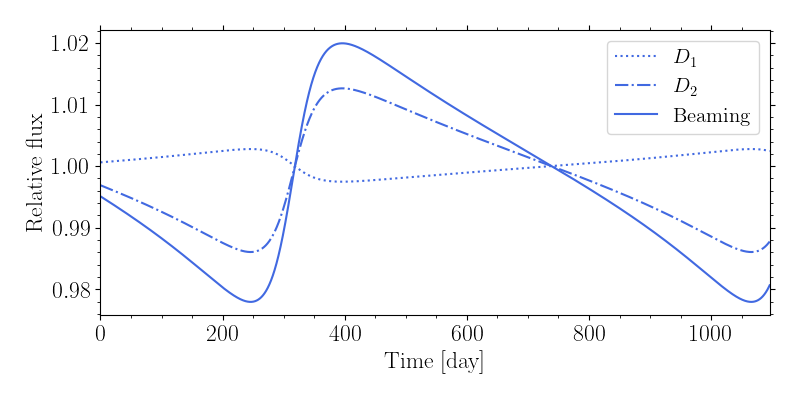

In [50]:
# Construct time array
D1, D2 = model.doppler_boosting(z, t0, P, M1, M2, i, e, w, alpha)
flux_beam = (1 - F_lum) * D1**(3 - alpha) + F_lum * D2**(3 - alpha)
flux_beam = (flux_beam - 1)*2 + 1

fig = plt.figure(figsize = (8, 4))
plt.plot(time.to('d'), D1,       ':',  c='royalblue', label=r"$D_1$")
plt.plot(time.to('d'), D2,       '-.', c='royalblue', label=r"$D_2$")
plt.plot(time.to('d'), flux_beam, '-', c='royalblue', label=r"Beaming")
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.legend()
plt.tight_layout()

### QSO variability (red noise)

<IPython.core.display.Javascript object>


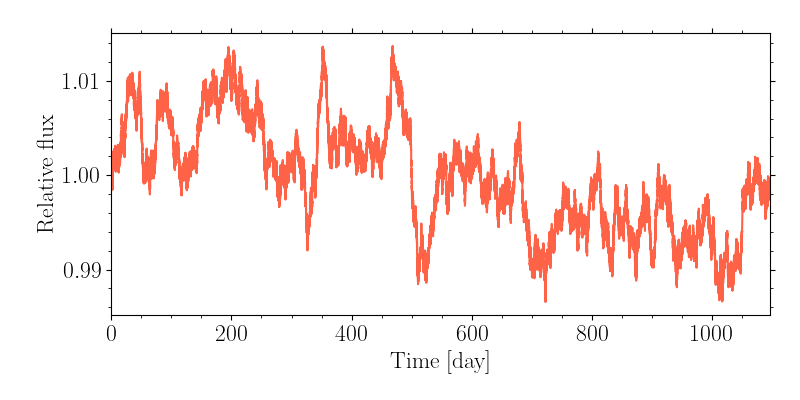

In [51]:
tau   = np.array([50]) * u.d
sigma = np.array([30]) # ppm

flux_red = model.quasar_variability(tau, sigma)

fig = plt.figure(figsize = (8, 4))
plt.plot(time.to('d'), flux_red, color='tomato')
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.tight_layout()

<IPython.core.display.Javascript object>


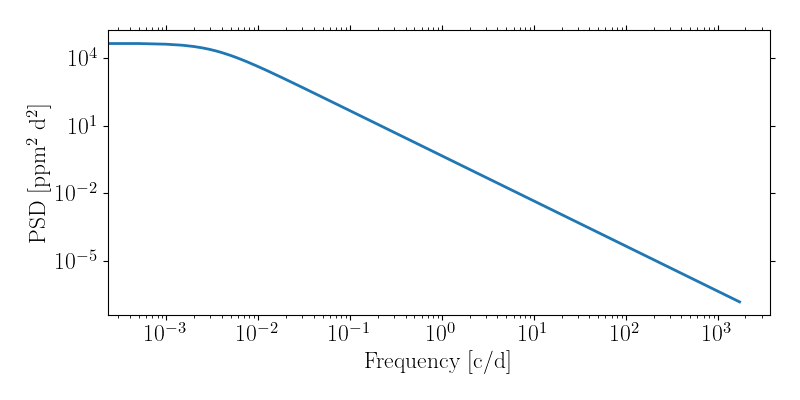

In [10]:
Nfreq = time.shape[0]
freq = np.arange(float(Nfreq)) / (Nfreq-1) * 0.5 / (dt * u.s).to('d').value
PSD = ns.modelRedNoisePSD(freq, tau.to('d').value, sigma)

fig = plt.figure(figsize = (8, 4))
for i in range(len(tau)):
    plt.loglog(freq, PSD, lw=2)
plt.xlabel(r"Frequency [c/d]")
plt.ylabel(r"PSD [ppm$^2$ d$^2$]")
plt.tight_layout()
plt.show()

### Combined model

<IPython.core.display.Javascript object>


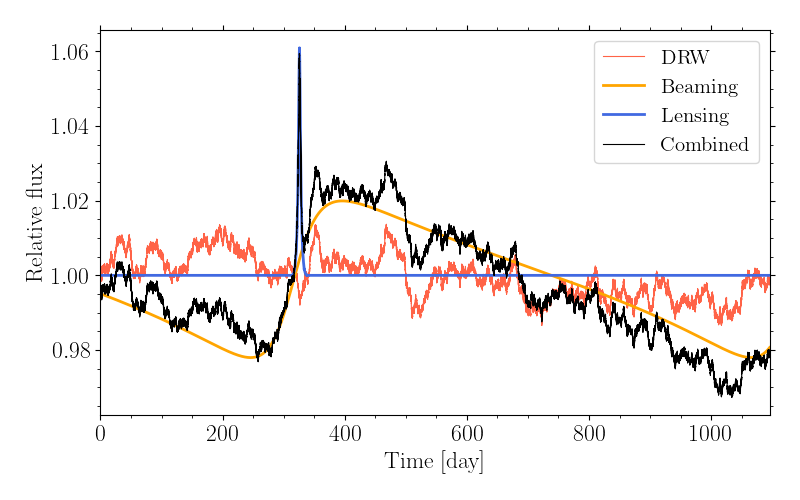

In [52]:
# Combined model (Beaming + QSO varibility)
flux = flux_beam * flux_red * flux_lens

# Plotting the combined (Doppler + Stochastic Quasar Variability) model
fig = plt.figure(figsize = (8, 5))
# plt.plot(time.to('d'), np.ones_like(time), '--', c='k')
plt.plot(time.to('d'), flux_red,  color='tomato',    label="DRW", lw=0.8)
plt.plot(time.to('d'), flux_beam, color='orange',    label="Beaming", lw=2)
plt.plot(time.to('d'), flux_lens, color='royalblue', label="Lensing", lw=2)
plt.plot(time.to('d'), flux,      color='k',         label="Combined", lw=0.8)
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.legend()
plt.tight_layout()

# Save figure
# fig.savefig(f'{fdir}/spikey_model.png', bbox_inches='tight', dpi=300)

In [105]:
ofile = f'{path}/input/varsource_spikey.txt'
data = np.transpose([time, -2.5*np.log10(flux)])
# np.savetxt(ofile, data, fmt=['%.1f', '%.8f'])

<IPython.core.display.Javascript object>


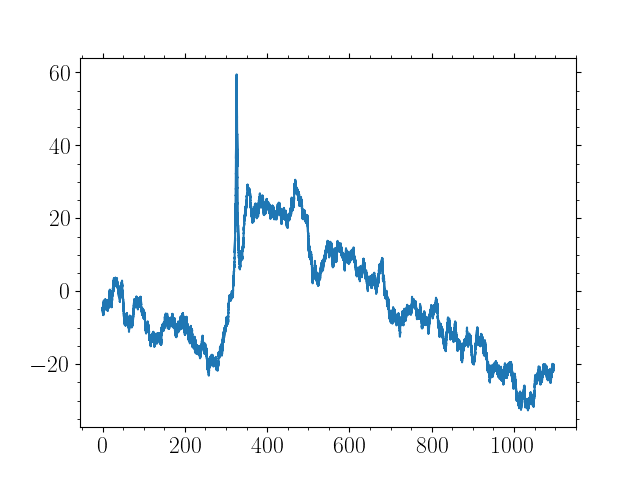

In [107]:
plt.figure()
# plt.plot(data[:,0], data[:,1])
plt.plot(time/86400, (flux-1)*1e3)

<IPython.core.display.Javascript object>


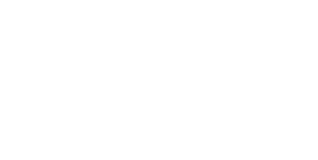

In [37]:
# Combined model (Beaming + QSO varibility)
flux = flux_beam * flux_red * flux_lens

# Plotting the combined (Doppler + Stochastic Quasar Variability) model
fig = plt.figure(figsize=(3.18,1.6))
plt.plot(time.to('d'), flux, color='w', lw=0.8)
plt.xlim(0, time.to('d').value[-1])
plt.tight_layout()
plt.xticks([])
plt.yticks([])
plt.axis('off')

# Save figure
# Save figure
tdir = '/lhome/nicholas/Nextcloud/thesis/image'
# fig.savefig(f'{tdir}/lightcurve_smbhb.png', bbox_inches='tight', dpi=300, transparent=True)

---
## HPC local for Spikey
---

In [455]:
 from platosim.hpc import HPC

In [461]:
# starcat = f'{path}/input/starcat_ICRFJ191845.5+493756.ftr'
# varfile = f'{path}/input/varsource_spikey.txt'
# kwargs = f'--seed 12345 --cadence 600 --starcat {starcat} --varfile {varfile}'

varfile = f'{path}/input/varsource_spikey.txt'
kwargs = f'--seed 12345 --cadence 600 --mag 18 --varfile {varfile} -w'

# Parse arguments
hpc = HPC('smbhb', cpus=6)
hpc.run(script='platonium', param_file='cluster_ncam.data', kwargs=kwargs) 

100%|██████████████████████████████████████████████████| 264/264 [46:16<00:00, 1


### Quick simulations

In [163]:
# Load light curves
filename = f'{path}/output/000000001'
lcs = LightCurve(filename, mode="multi")
files = lcs.files(suffix='hdf5')
# files

<IPython.core.display.Javascript object>


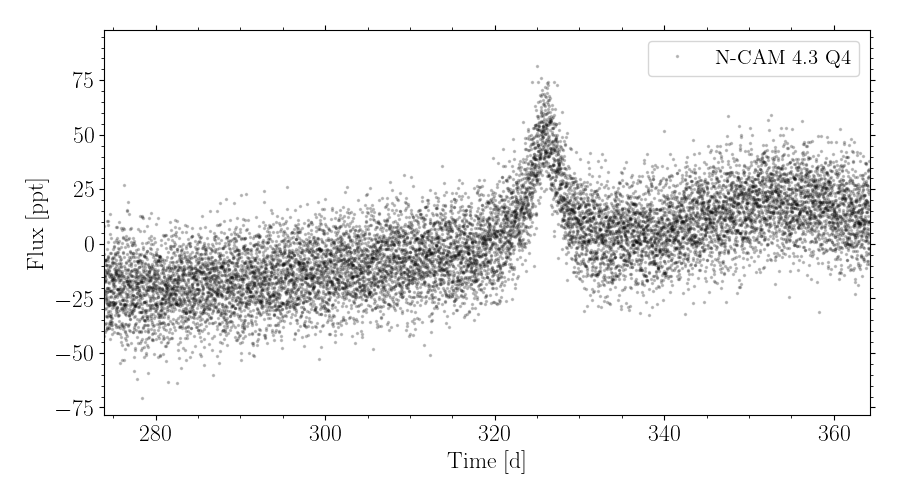

(<Figure size 900x500 with 1 Axes>,
 <Axes: xlabel='Time [d]', ylabel='Flux [ppt]'>)

In [164]:
lc = LightCurve(files[60], mode="single")
lc.plot(flux_unit='ppt')
# lc.data().diff()

<IPython.core.display.Javascript object>


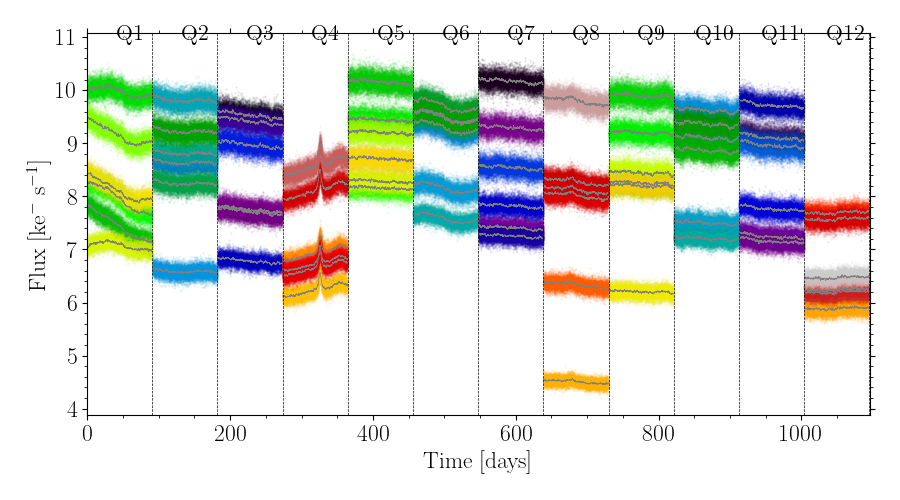

In [165]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))